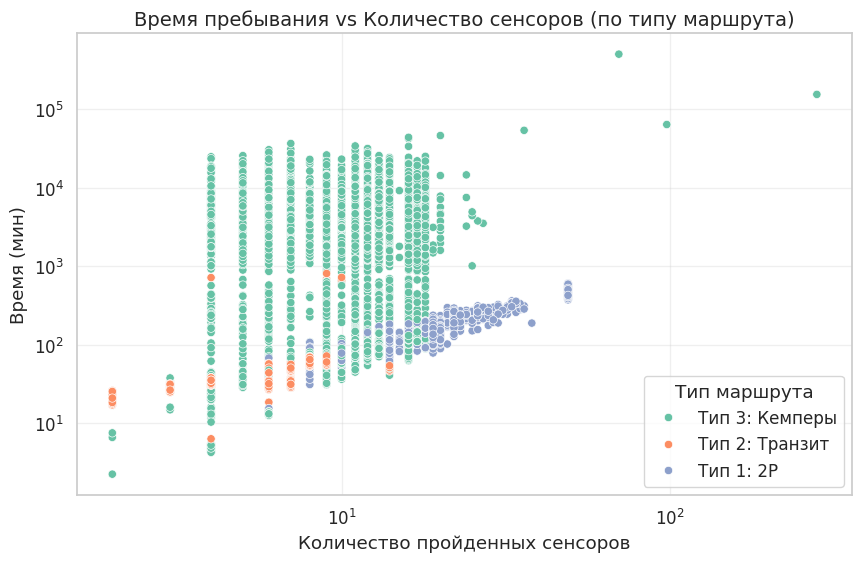

In [4]:
#scatter плот: время пребывания/количество пройденных сенсоров + покрасить точки по типу маршрута
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля для красивых графиков
sns.set(style="whitegrid")

# --- ЧТЕНИЕ ДАННЫХ ---
# Считываем данные из файла
df = pd.read_csv("../data/sensors.csv")

# Переименование колонок
df = df.rename(columns={
    'Timestamp': 'timestamp',
    'car-id': 'car_id',
    'car-type': 'car_type',
    'gate-name': 'gate_name',
})

# Преобразование типов
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['car_id'] = df['car_id'].astype('string')
df['car_type'] = df['car_type'].astype('category')
df['gate_name'] = df['gate_name'].astype('category')

# Сортировка
df = df.sort_values(['car_id', 'timestamp']).reset_index(drop=True)

# --- ЛОГИКА КЛАССИФИКАЦИИ ---
def get_route_type(group):
    """
    Определяет тип маршрута для группы строк с одинаковым car_id.
    Логика:
    1. Если  '2P' -> Тип 1
    2. Иначе если есть ворота с 'ranger' или 'camping' -> Тип 3 (Кемперы)
    3. Иначе -> Тип 2 (Обычный)
    """
    car_type = group['car_type'].iloc[0]
    gates = group['gate_name'].unique().tolist()
    
    # Проверка на "2P"
    if '2P' in str(car_type):
        return 'Тип 1: 2P'
    
    # Проверка на кемперы (ranger/camping)
    # Ищем в названиях ворот
    has_camping = any('camp' in str(g).lower() for g in gates)
    
    if has_camping:
        return 'Тип 3: Кемперы'
    else:
        return 'Тип 2: Транзит'

# --- АГГРЕГАЦИЯ И ВИЗУАЛИЗАЦИЯ ---

# 1. Группировка и классификация
# Создаем список для результатов
results = []

# Итерируем по группам car_id
for car_id, group in df.groupby('car_id'):
    # Определяем тип маршрута для этой группы
    route_type = get_route_type(group)
    
    # Считаем количество сенсоров (строки в группе)
    sensors_count = len(group)
    
    # Считаем время (разница между макс и мин timestamp)
    time_spent = (group['timestamp'].max() - group['timestamp'].min()).total_seconds() / 60
    
    results.append({
        'car_id': car_id,
        'sensors_count': sensors_count,
        'time_spent': time_spent,
        'route_type': route_type
    })

# Преобразуем в DataFrame
summary_df = pd.DataFrame(results)

# --- ПОСТРОЕНИЕ ГРАФИКА ---
plt.figure(figsize=(10, 6))
sns.set_context("notebook", font_scale=1.1)

# Scatter plot: x = sensors_count, y = time_spent, цвет = route_type
ax = sns.scatterplot(data=summary_df, x='sensors_count', y='time_spent', hue='route_type', palette="Set2")

# --- ЛОГИРОВАНИЕ ШКАЛ
ax.set_xscale('log')
ax.set_yscale('log')

plt.title('Время пребывания vs Количество сенсоров (по типу маршрута)', fontsize=14)
plt.xlabel('Количество пройденных сенсоров')
plt.ylabel('Время (мин)')
plt.legend(title='Тип маршрута')
plt.grid(True, alpha=0.3)
plt.show()

# Вывод данных для проверки
# print("Итоговая таблица для графика:")
# print(summary_df[['car_id', 'sensors_count', 'time_spent', 'route_type']])


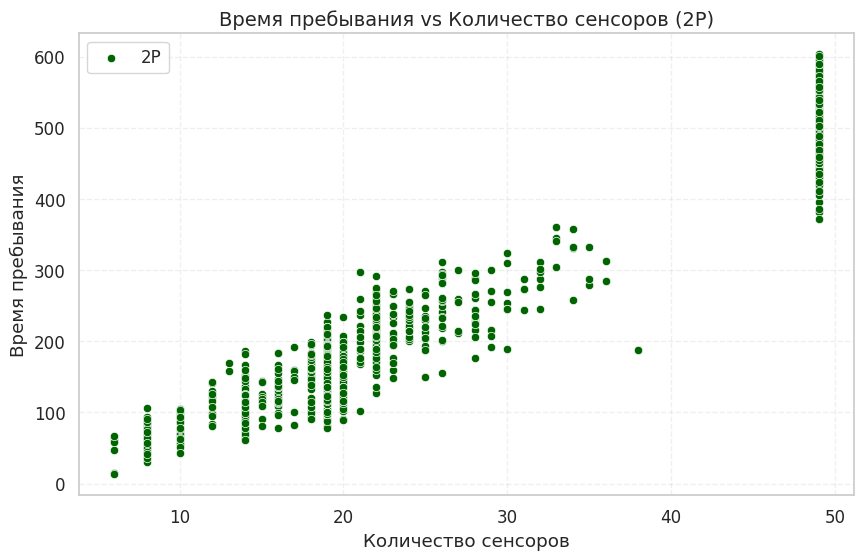

In [7]:

df_2p = summary_df[summary_df['route_type'] == 'Тип 1: 2P']

if not df_2p.empty:
    plt.figure(figsize=(10, 6))
    sns.set_context("notebook", font_scale=1.1)

    ax2 = sns.scatterplot(data=df_2p, x='sensors_count', y='time_spent', color='darkgreen', label='2P')

    # ax2.set_xscale('log')
    # ax2.set_yscale('log')

    plt.title('Время пребывания vs Количество сенсоров (2P)', fontsize=14)
    plt.xlabel('Количество сенсоров')
    plt.ylabel('Время пребывания')
    plt.legend()
    plt.grid(True, which="both", axis='both', alpha=0.3, linestyle='--')
    plt.show()
else:
    print("Aucun véhicule de type '2P' trouvé dans les données.")
